# 01 — Map-matching sanity check

Visual QC of `LeuvenMapMatcher` (design doc §13.3): eyeball 5–10 matched fixture
trajectories over the Haidian network slice **before trusting the matcher at scale**.

Red ✕ = raw GPS (projected). Blue = points snapped onto the matched road edges.
Each title shows the quality numbers; `PASS`/`FAIL` is the `min_match_score=0.6` gate.

Run from `notebooks/` with the `notebooks` dependency group:
`uv run --group notebooks jupyter nbconvert --to notebook --execute --inplace 01_matching_sanity.ipynb`

In [1]:
import json
from pathlib import Path

import pandas as pd

from trajguard.datasets import CleaningConfig, GeolifeLoader, clean
from trajguard.maps import OSMMapSource
from trajguard.matching import LeuvenMapMatcher, mean_offset_m, passes_quality

FIXTURES = Path("..") / "tests" / "fixtures"
manifest = json.loads((FIXTURES / "geolife" / "MANIFEST.json").read_text(encoding="utf-8"))
AREA = tuple(manifest["area_west_south_east_north"])

net = OSMMapSource(
    region="beijing", bbox=AREA, crs="EPSG:32650", maps_dir=FIXTURES / "maps"
).load()
cfg = CleaningConfig()
matcher = LeuvenMapMatcher()  # calibrated defaults (see class docstring)

cleaned = [
    c
    for c in (clean(r, cfg) for r in GeolifeLoader(FIXTURES / "geolife").iter_trajectories())
    if c is not None
]
matches = {c.traj_id: (c, matcher.match(c, net)) for c in cleaned}

table = pd.DataFrame(
    {
        "traj_id": tid,
        "n_points": len(c.points),
        "frac_matched": round(m.frac_matched, 2),
        "match_score": round(m.match_score, 3),
        "mean_offset_m": round(mean_offset_m(m), 1) if m.matched_points else float("nan"),
        "n_edges": len(m.edge_seq),
        "passes_0.6": passes_quality(m),
    }
    for tid, (c, m) in matches.items()
).sort_values("match_score", ascending=False).reset_index(drop=True)
table

Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


...

Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


Searching closeby nodes with linear search, use an index and set max_dist


,traj_id,n_points,frac_matched,match_score,mean_offset_m,n_edges,passes_0.6
0,000_20090516091038,150,1.00,0.946,8.1,16,True
1,000_20090703002800,147,1.00,0.930,10.6,20,True
2,001_20081106133604,101,1.00,0.929,10.7,14,True
3,000_20090702022530,137,1.00,0.884,17.5,13,True
4,001_20081026081229,125,1.00,0.849,22.7,28,True
5,001_20081106051423,100,1.00,0.776,33.6,23,True
6,001_20081105110052,132,1.00,0.772,34.3,21,True
7,001_20081028235048,95,0.74,0.560,36.1,25,False
8,001_20081027111634,116,0.82,0.402,76.3,7,False
9,000_20081110013637,149,0.52,0.389,38.4,45,False


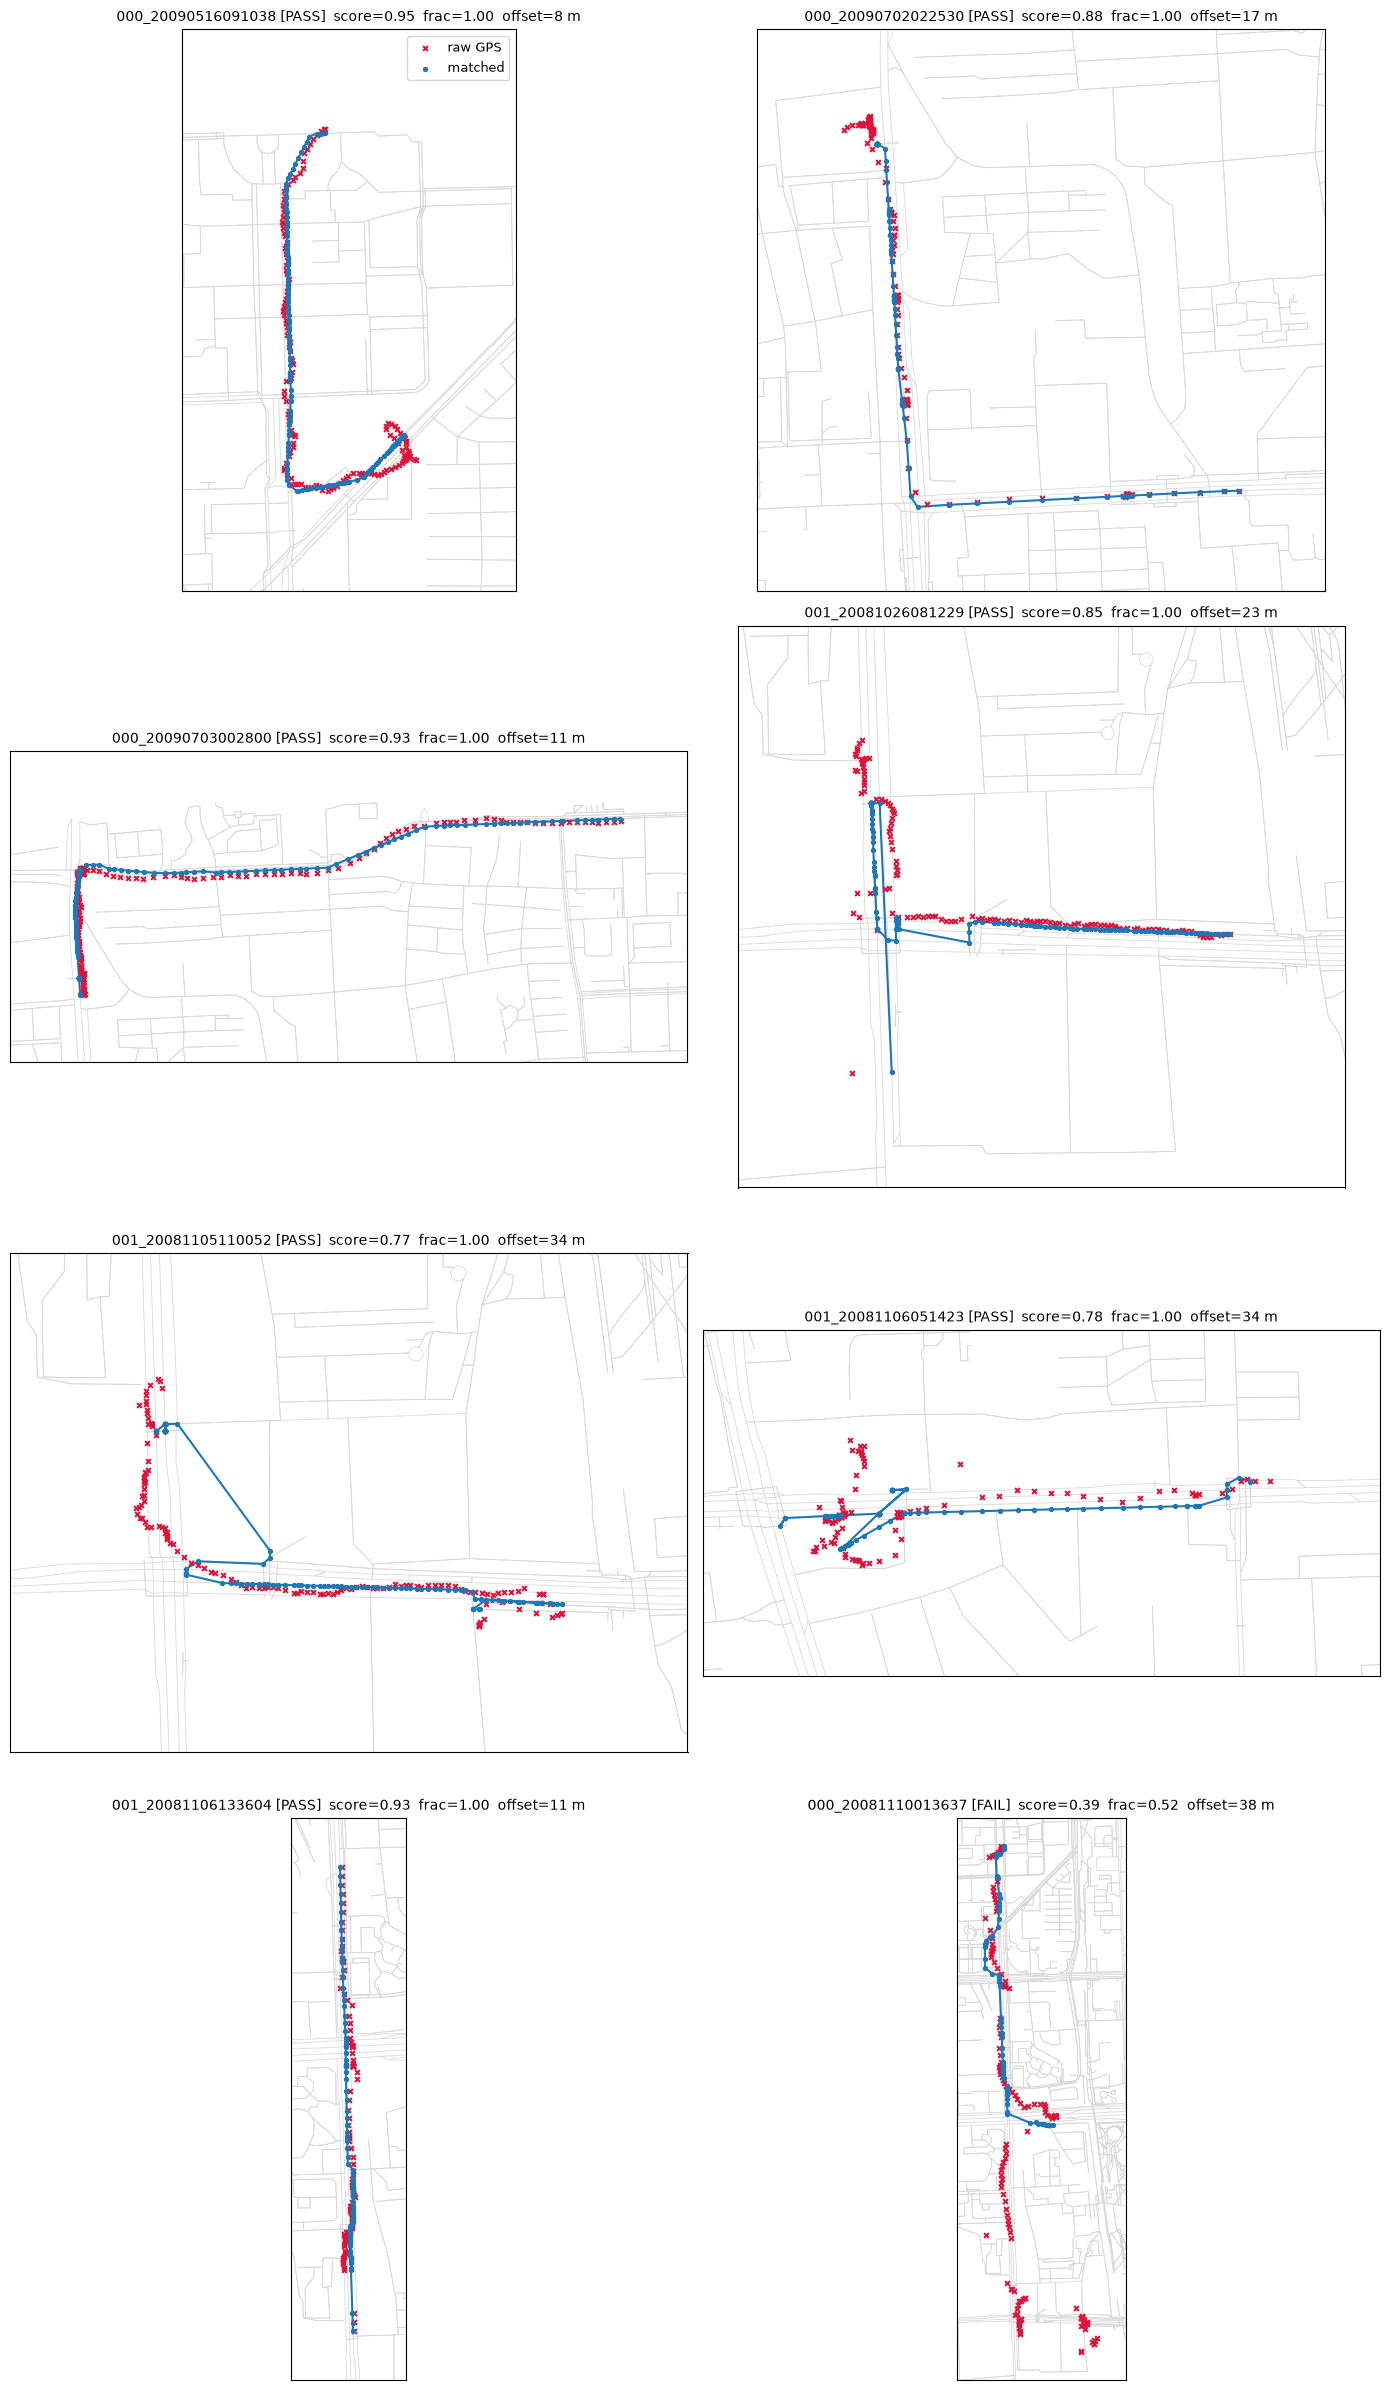

In [2]:
import matplotlib.pyplot as plt
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", net.crs, always_xy=True)
passing = [tid for tid, (_, m) in matches.items() if passes_quality(m)]
failing_partial = [
    tid for tid, (_, m) in matches.items() if not passes_quality(m) and m.matched_points
]
show = passing[:8] + failing_partial[:1]  # 5-10 tracks + one FAIL for contrast

ncols = 2
nrows = -(-len(show) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
for ax, tid in zip(axes.flat, show, strict=False):
    c, m = matches[tid]
    net.edges.plot(ax=ax, color="0.85", linewidth=0.6, zorder=1)
    gx, gy = zip(*[transformer.transform(p.lon, p.lat) for p in c.points], strict=True)
    ax.scatter(gx, gy, s=12, c="crimson", marker="x", label="raw GPS", zorder=3)
    if m.matched_points:
        sx = [p.x for p in m.matched_points]
        sy = [p.y for p in m.matched_points]
        ax.plot(sx, sy, c="tab:blue", lw=1.5, zorder=2)
        ax.scatter(sx, sy, s=8, c="tab:blue", label="matched", zorder=4)
    pad = 150
    ax.set_xlim(min(gx) - pad, max(gx) + pad)
    ax.set_ylim(min(gy) - pad, max(gy) + pad)
    status = "PASS" if passes_quality(m) else "FAIL"
    ax.set_title(
        f"{tid} [{status}]  score={m.match_score:.2f}  "
        f"frac={m.frac_matched:.2f}  offset={mean_offset_m(m):.0f} m",
        fontsize=10,
    )
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes.flat[len(show) :]:
    ax.axis("off")
axes.flat[0].legend(loc="upper right", fontsize=9)
fig.tight_layout()

## Reading the result

- **PASS tracks** should show blue hugging the grey street geometry with red ✕
  scattered tightly around it (GPS noise) — mean offsets ≈ 8–40 m.
- **FAIL tracks** are dropped by the `min_match_score=0.6` gate: typically campus
  interiors/parks where the trace leaves the mapped network, or heavy warm-up drift.
  Dropping them is the intended behaviour (design doc risk T2), and the drop *rate*
  must be reported alongside attack results.
- Calibration note: defaults `max_dist_init=100`, `obs_noise=75` were chosen on this
  fixture; the drive-only network was replaced by `network_type="all"` because
  Geolife is mixed-mode — see `LeuvenMapMatcher` docstring and PR discussion.